In [28]:
# Отключить верхний порог MPS
import os
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

# Pre test

In [29]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image
import torch

In [30]:
# Загрузка модели и процессора
model_id = "google/owlv2-base-patch16-ensemble"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

In [31]:
# Загрузка изображения
image = Image.open("../data/fridge.jpg")

In [44]:
# Тексты объектов, которые хотим найти
texts = [[    
    # Фрукты и овощи
    "apple", "banana", "orange", "cucumber", "redish",
    "carrot", "potato", "onion", "green onion", "tomato", "lettuce", "red pepper", "yellow pepper", "broccoli", "cabbage", "eggplant", "zucchini", "pumpkin", "garlic", "ginger", "lemon", "lime", "watermelon", "grape", 
    "strawberry", "blueberry", "raspberry", "kiwi", "peach", "plum", "pear", "cherry", "pineapple",
    "mango", "papaya", "pomegranate", "coconut", "apricot", "tangerine", "radish", "beet",
    
    # Мясо и птица
    "chicken breast", "chicken thigh", "whole chicken", "ground beef", "pork chop", "bacon", 
    "sausage", "turkey", "ham", "steak", "lamb chop", "egg",

    # Молочные продукты
    "milk", "butter", "cream", "sour cream", "cottage cheese", "kefir", "ice cream", "cheese", "yogurt",
    "mozzarella", "feta cheese", "parmesan cheese", "cheddar cheese", "blue cheese",

    # Рыба и морепродукты
    "salmon", "tuna", "shrimp", "cod", "herring", "crab", "mussels",

    # Бакалея
    "rice", "pasta", "spaghetti", "noodles", "oatmeal", "buckwheat", "flour", "bread",
    "sugar", "salt", "black pepper", "olive oil", "vegetable oil", "vinegar", "soy sauce",

    # Соусы и приправы
    "mayonnaise", "ketchup", "mustard", "barbecue sauce", "hot sauce", "curry powder"
]]

# Предобработка
inputs = processor(text=texts, images=image, return_tensors="pt", padding=True).to(device)

In [45]:
# Предсказание
with torch.no_grad():
    outputs = model(**inputs)

In [46]:
# Постобработка (превращение логитов в боксы и лейблы)
results = processor.post_process_grounded_object_detection(outputs, threshold=0.2, target_sizes=[image.size])[0]

In [47]:
# Пример вывода
for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
    print(f"Object: {texts[0][label]}, Score: {score:.2f}, Box: {box.tolist()}")

Object: cabbage, Score: 0.23, Box: [194.87803649902344, 181.60365295410156, 313.7327880859375, 291.38507080078125]
Object: eggplant, Score: 0.44, Box: [620.8267211914062, 182.38868713378906, 959.742919921875, 455.8252868652344]
Object: cabbage, Score: 0.70, Box: [196.55130004882812, 184.83074951171875, 551.0349731445312, 451.991455078125]
Object: cabbage, Score: 0.39, Box: [248.18792724609375, 232.90081787109375, 428.1255187988281, 449.5733337402344]
Object: cabbage, Score: 0.27, Box: [422.3910217285156, 218.40948486328125, 533.0704956054688, 325.3463439941406]
Object: cabbage, Score: 0.27, Box: [188.72836303710938, 181.02120971679688, 319.9637451171875, 442.05487060546875]
Object: strawberry, Score: 0.24, Box: [783.060546875, 290.1732482910156, 856.3679809570312, 356.6473693847656]
Object: lime, Score: 0.40, Box: [355.59967041015625, 269.40960693359375, 478.0859680175781, 381.1013488769531]
Object: cucumber, Score: 0.31, Box: [480.2831726074219, 278.8553161621094, 599.35986328125, 394

In [48]:
# Визуализация результатов
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_results(image, results):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
        x0, y0, x1, y1 = box.tolist()
        width, height = x1 - x0, y1 - y0
        rect = patches.Rectangle((x0, y0), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x0, y0 - 10, f"{texts[0][label]}: {score:.2f}", color='white', fontsize=12,
                bbox=dict(facecolor='red', alpha=0.5))

    plt.axis('off')
    plt.show()

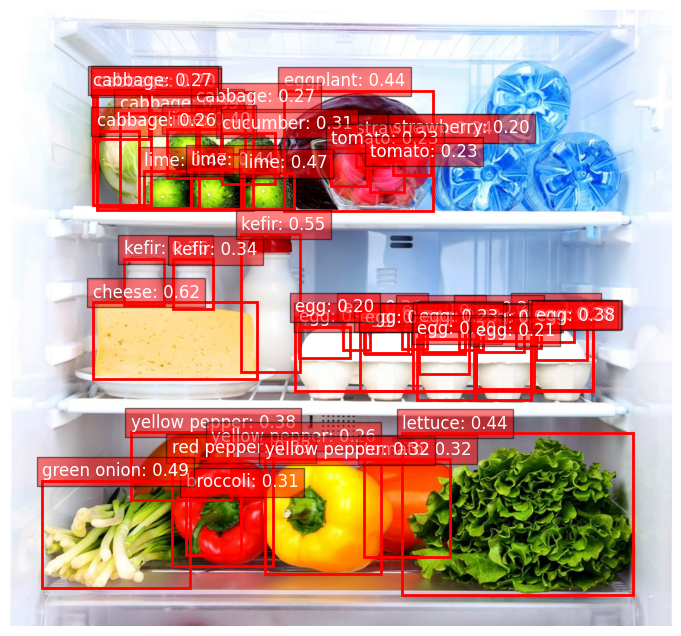

In [49]:
plot_results(image, results)

In [11]:
# Сохранение
model.save_pretrained("owlv2")

In [12]:
import torch
from pathlib import Path
from transformers import AutoProcessor
from optimum.onnxruntime import ORTModel

# 1. Загрузка модели и процессора
model_id = "google/owlv2-base-patch16-ensemble"
onnx_path = Path("owlv2-onnx")

# Загружаем процессор
processor = AutoProcessor.from_pretrained(model_id)

# Загружаем модель и сразу экспортируем ее в ONNX
# Модель будет сохранена в директории, указанной в onnx_path
model = ORTModel.from_pretrained(
    model_id,
    export=True,
)

# Сохраняем процессор вместе с моделью для удобства
processor.save_pretrained(onnx_path)
model.save_pretrained(onnx_path)

print(f"Модель и процессор сохранены в формате ONNX в директории: '{onnx_path}'")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/Users/infibiss/Desktop/Fridge-Recipe-Detector/.venv/lib/python3.11/site-packages/transformers/models/owlv2/modeling_owlv2.py:341: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if interpolate_pos_encoding:
/Users/infibiss/Desktop/Fridge-Recipe-Detector/.venv/lib/python3.11/site-packages/transformers/models/owlv2/modeling_owlv2.py:430: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data

Модель и процессор сохранены в формате ONNX в директории: 'owlv2-onnx'


# Fine-tuning

In [41]:
from datasets import load_dataset, Image
from transformers import TrainingArguments, Trainer, Owlv2Processor, Owlv2ForObjectDetection

In [42]:
# 1. Загрузка каталогизированного датасета
dataset = load_dataset("imagefolder", 
                       data_dir="../data",     
                       split={"train": "train", "validation": "validation"}, 
                       drop_labels=False)

dataset = dataset.cast_column("image", Image())


In [43]:
# 2. Инициализация процессора
model_id_patch32 = "google/owl-vit-base-patch32"
processor = AutoProcessor.from_pretrained(model_id)

In [44]:
# 3. Препроцессинг: текстовые подсказки для классов
class_names = dataset["train"].features["label"].names
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    # prompts = [class_names[label] for label in examples["label"]]
    prompts = [[class_names[label]] for label in examples["label"]]

    features = processor(
        text=prompts,
        images=images,
        return_tensors="np",
        padding=True
    )
    features["labels"] = examples["label"]
    return features

dataset = dataset.map(preprocess, batched=True, remove_columns=["image", "label"])


Map: 100%|██████████| 1/1 [00:00<00:00,  6.67 examples/s]


In [45]:
# 4. Модель с классификационной головой
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id, num_labels=len(class_names))

In [51]:
# 5. Параметры обучения и Trainer
training_args = TrainingArguments(
    output_dir="owlv2",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    eval_strategy="steps",
    save_steps=100,
    num_train_epochs=3,
    logging_steps=50
)

import torch.nn.functional as F
class OWLv2Trainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Извлекаем метки из входных данных
        labels = inputs.pop("labels", None)
        
        # Получаем выходные данные модели
        outputs = model(**inputs)
        
        # Получаем логиты для классификации
        # В OWLv2 логиты представляют уверенность модели в обнаружении объекта
        logits = outputs.logits
        
        # Вычисляем потери для задачи классификации
        # Можно использовать средний логит для каждого изображения или максимальный
        # В зависимости от вашей задачи
        image_logits = torch.max(logits, dim=1)[0]  # Берем максимальный логит по всем обнаруженным объектам
        
        # Вычисляем кросс-энтропию для классификации
        loss = F.cross_entropy(image_logits, labels)
        
        return (loss, outputs) if return_outputs else loss

trainer = OWLv2Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=processor,
)

/var/folders/rl/jzw71c0n4996k6j_58f9r13w0000gn/T/ipykernel_43818/1076641608.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `OWLv2Trainer.__init__`. Use `processing_class` instead.
  trainer = OWLv2Trainer(


In [52]:
# 6. Fine-tuning
trainer.train()

TypeError: cross_entropy_loss(): argument 'target' (position 2) must be Tensor, not NoneType

In [ ]:
# 7. Оценка модели
inputs = processor(text=texts, images=image, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
results = processor.post_process_grounded_object_detection(outputs, threshold=0.2, target_sizes=[image.size])[0]
plot_results(image, results)